# Logistic Regression

---
Also called *Logit Regression* is commonly used to estimate the probability that an instance belongs to a particular class (e.g., what is the probability that this email is spam?). If the estimated probability is greater than $50$%, then the model preidcts that the instance belongs to that class (called the positive class, labeled "1"), and otherwise it predicts that it does not (i.e., it belongs to the negative class, labeled "0"). This make it a binary classification

---

> Logistic Regression model estimated probability (vectorized form)
>
$$\hat {p} = \sigma(X^T \theta)$$

In [1]:
from sklearn.datasets import make_classification
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0, n_classes = 2, n_clusters_per_class = 1, random_state = 41, hypercube = False, class_sep = 30)
X.shape, y.shape

((100, 2), (100,))

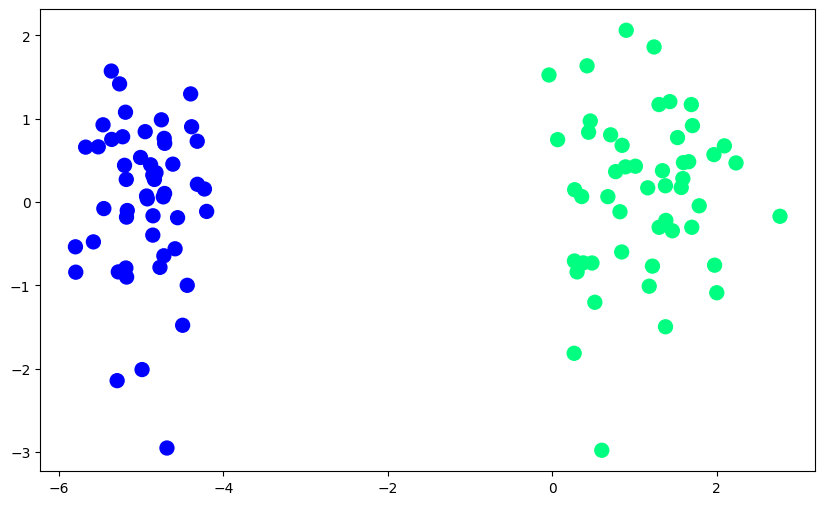

In [3]:
plt.figure(figsize = (10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)

In [4]:
# probability calculation function
def step(z):
    return 1 if z > 0 else 0

In [5]:
def perceptron(X,y):
    # insert 1s column
    X = np.insert(X, 0, 1, axis = 1)

    # initialize weights matrix with all 1
    weights = np.ones(X.shape[1])

    # learning rate
    learning_rate = 0.1

    for i in range(1000):
        # select a random student
        random_student = np.random.randint(0,X.shape[0])

        # predict if get placement or not - if probability >= 0 then yes; otherwise no
        y_pred = step(np.dot(X[random_student], weights))
        weights = weights + learning_rate*(y[random_student] - y_pred)*X[random_student]
        

    return weights[0], weights[1:]

In [6]:
intercept_, coef_ = perceptron(X, y)
intercept_, coef_

(np.float64(1.2000000000000002), array([1.1204053 , 0.40381514]))

In [7]:
# Calculate m and b
m = - (coef_[0]/coef_[1])
b = - (intercept_/coef_[1])
m,b

(np.float64(-2.7745500252190514), np.float64(-2.9716568071029252))

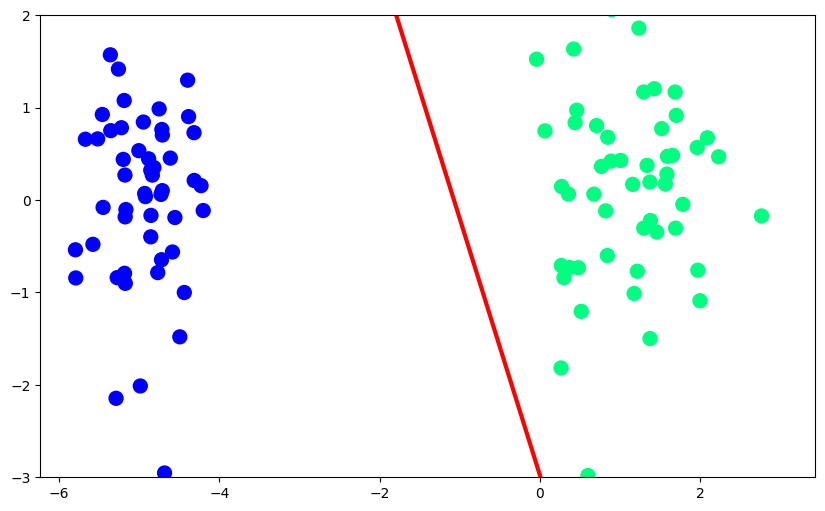

In [8]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

plt.figure(figsize = (10,6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.ylim(-3, 2)

plt.show()

In [10]:
def perceptron(X, y):
    m, b = [], []

    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    learning_rate = 0.1

    for i in range(200):
        random_points = np.random.randint(0, 100)
        y_pred = step(np.dot(X[random_points], weights))

        weights = weights + learning_rate*(y[random_points] - y_pred)*X[random_points]

        m.append(- (weights[1]/weights[2]))
        b.append(- (weights[0]/weights[2]))
    return m, b

In [11]:
m,b = perceptron(X, y)

In [12]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [13]:
fig, ax = plt.subplots(figsize = (9,5), dpi = 150)

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] + b[0]

ax.scatter(X[:, 0], X[:, 1], c = y, cmap = 'winter', s = 100)
line, = ax.plot(x_i, x_i*m[0] + b[0], 'r-', linewidth = 2)
plt.ylim(-3, 3)
def update(i):
    label = f'epoch {i+1}'
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)

anim = FuncAnimation(fig, update, repeat = True, frames = 200, interval = 100)

<IPython.core.display.Javascript object>

In [14]:
import imageio_ffmpeg
import matplotlib as mpl

mpl.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

print(imageio_ffmpeg.get_ffmpeg_exe())

C:\Users\HP\anaconda3\Lib\site-packages\imageio_ffmpeg\binaries\ffmpeg-win-x86_64-v7.1.exe


In [15]:
from IPython.display import HTML

HTML(anim.to_html5_video())

In [16]:
# Apply sklearn logistic regression
from sklearn.linear_model import LogisticRegression
logistic_reg = LogisticRegression()
logistic_reg.fit(X, y)
logistic_reg.intercept_, logistic_reg.coef_

(array([3.54700273]), array([[1.77255101, 0.01190507]]))

In [17]:
m = - (logistic_reg.coef_[0][0]/ logistic_reg.coef_[0][1])
b = - (logistic_reg.intercept_/ logistic_reg.coef_[0][1])

In [18]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

In [19]:
%matplotlib inline

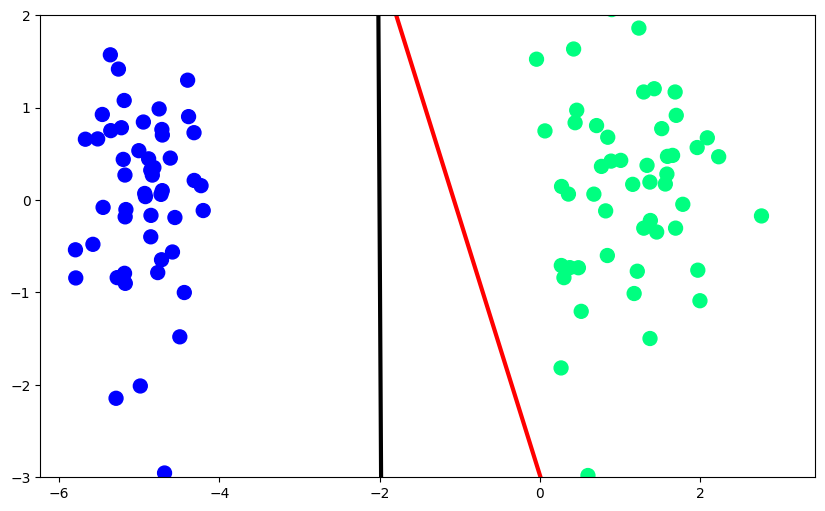

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.show()

In [21]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [22]:
def perceptron(X,y):
    # insert 1s column
    X = np.insert(X, 0, 1, axis = 1)

    # initialize weights matrix with all 1
    weights = np.ones(X.shape[1])

    # learning rate
    learning_rate = 0.1

    for i in range(1000):
        # select a random student
        random_student = np.random.randint(0,X.shape[0])

        # predict if get placement or not - if probability >= 0 then yes; otherwise no
        y_pred = sigmoid(np.dot(X[random_student], weights))
        weights = weights + learning_rate*(y[random_student] - y_pred)*X[random_student]
        

    return weights[0], weights[1:]

In [23]:
intercept_, coef_ = perceptron(X,y)
intercept_, coef_

(np.float64(2.586927682970104), array([2.31144384, 0.23702719]))

In [24]:
m =  - (coef_[0]/coef_[1])
b = - (intercept_/ coef_[1])
x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

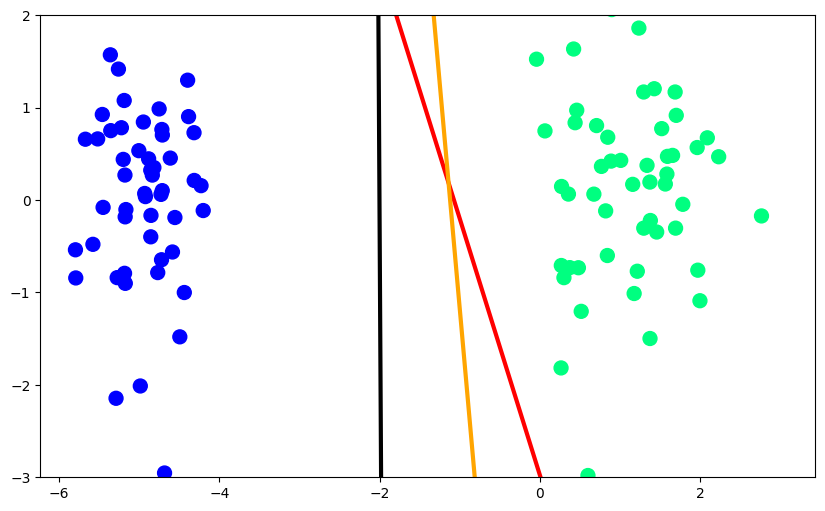

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.plot(x_input2, y_input2, color='orange', linewidth=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.show()